# ChemAI: Predict the Cure

## CatBoost Per-Target

Kaggle Score: 298.05

В данном решении исследуется влияние раздельного обучения таргетов на качество прогнозирования.

В отличие от базового решения, где одна модель одновременно предсказывает все три таргета, здесь для каждого таргета обучается отдельная модель CatBoost.

Цель эксперимента — проверить, улучшает ли независимое моделирование IC50, CC50 и SI качество решения.

### Структура ноутбука

1. Описание проекта
2. Подготовка окружения
3. Загрузка данных
4. Базовая проверка данных
5. Подготовка признаков
6. Удаление константных признаков
7. Метрика соревнования
8. Подготовка данных
9. Настройка кросс-валидации
10. Обучение отдельных моделей
11. OOF-оценка качества
12. Анализ результатов
13. Формирование submission
14. Итоговый вывод
15. Воспроизводимость

### Цель эксперимента

В базовом решении использовалась одна модель для одновременного предсказания трёх таргетов.

Однако разные биологические показатели могут иметь различную природу и сложность прогнозирования.

Поэтому в данном эксперименте для каждого таргета обучается отдельная модель CatBoost.

Предполагается, что независимое обучение позволит моделям лучше адаптироваться к особенностям каждого таргета.

Таргеты:

- IC50 — концентрация подавления вируса;
- CC50 — концентрация токсичности;
- SI — индекс селективности.

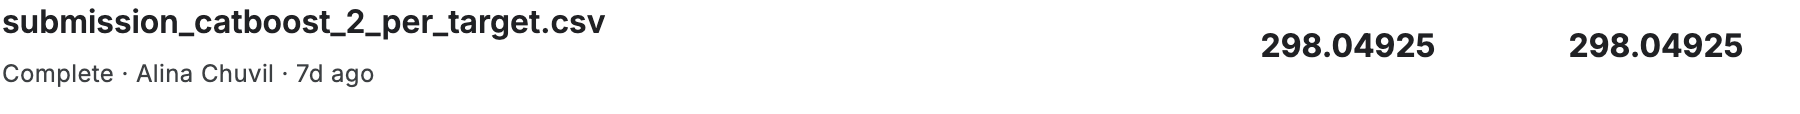

## Подготовка окружения

Импортируем библиотеки, фиксируем seed и создаём конфигурацию проекта.

In [1]:
!pip install -q catboost

import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from catboost import CatBoostRegressor

SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything()


## 1. Загрузка данных  

Загружаем обучающую выборку, тестовую выборку и шаблон submission-файла.

После загрузки проверяем размеры датасетов.

In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

print(train.shape)
print(test.shape)
print(sample_submission.shape)

train.head()

(751, 214)
(250, 211)
(250, 4)


,index,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,102.414420,95.757483,0.935000,5.466584,5.466584,0.719259,0.719259,0.681165,18.307692,...,1,0,0,0,0,0,0,0,0,0
1,1,0.044333,8.401080,189.500000,11.492712,11.492712,0.012350,-3.798024,0.769122,27.652174,...,0,1,0,0,0,0,0,0,0,0
2,2,4.437964,50.085589,11.285714,5.366084,5.366084,0.522930,0.522930,0.612606,24.608696,...,0,0,0,0,0,0,0,0,0,0
3,3,6.827881,682.788051,100.000000,13.317130,13.317130,0.020658,-4.829339,0.345823,12.400000,...,0,0,1,0,0,0,0,0,0,0
4,4,2.003253,70.001455,34.943894,6.320833,6.320833,0.300347,0.300347,0.562066,60.272727,...,0,0,0,0,0,0,0,0,0,0


In [3]:
print("Пропуски в train:")
display(train.isna().sum().sort_values(ascending=False).head())

print("Пропуски в test:")
display(test.isna().sum().sort_values(ascending=False).head())

print("Дубликаты train:", train.duplicated().sum())
print("Дубликаты test:", test.duplicated().sum())

Пропуски в train:


MinAbsPartialCharge    2
BCUT2D_LOGPHI          2
BCUT2D_MWHI            2
MaxAbsPartialCharge    2
MinPartialCharge       2
dtype: int64

Пропуски в test:


BCUT2D_MRLOW     1
BCUT2D_MRHI      1
BCUT2D_MWHI      1
BCUT2D_CHGLO     1
BCUT2D_LOGPHI    1
dtype: int64

Дубликаты train: 0
Дубликаты test: 0


### Вывод

В данных отсутствуют критические проблемы качества.

Можно переходить к подготовке признаков и обучению моделей.

Нормализация таргетов

In [4]:
train.columns = [c.strip().replace(", mM", "").replace(" ", "_") for c in train.columns]
test.columns = [c.strip().replace(", mM", "").replace(" ", "_") for c in test.columns]
sample_submission.columns = [c.strip().replace(", mM", "").replace(" ", "_") for c in sample_submission.columns]

В исходных данных названия колонок содержали пробелы, запятые и единицы измерения (например, "IC50, mM"). Мы удалили все лишние символы, чтобы упростить обращение к колонкам в коде. Это чисто техническое изменение, не влияющее на предсказания.

## 2. Базовая проверка данных

Проверяем размеры, типы признаков, пропуски, дубликаты, распределение таргетов.

# Подготовка признаков

Целевые переменные:

- IC50
- CC50
- SI

Колонка index используется только как идентификатор объекта и не участвует в обучении.

Все остальные признаки используются в качестве входных переменных модели.

In [5]:
TARGETS = ["IC50", "CC50", "SI"]
ID_COL = "index"

features = [
    c for c in train.columns
    if c not in TARGETS + [ID_COL]
]

print("Число признаков до очистки:", len(features))

Число признаков до очистки: 210


### Удаление константных признаков

Константные признаки содержат одно и то же значение для всех объектов.

Такие признаки не несут полезной информации и могут быть удалены без потери качества модели.

In [6]:
constant_cols = [
    c for c in features
    if train[c].nunique() <= 1
]

print("Constant columns:", len(constant_cols))

features = [
    c for c in features
    if c not in constant_cols
]

print("Число признаков после очистки:", len(features))

Constant columns: 18
Число признаков после очистки: 192


### Вывод

Из обучающей выборки удалены признаки без вариативности.

Это позволяет уменьшить размерность признакового пространства и снизить влияние шума.

### CV метрика - Метрика соревнования

Качество решения оценивается по среднему RMSE для трёх таргетов:

- IC50
- CC50
- SI

Для воспроизведения метрики Kaggle реализуем собственную функцию оценки.

In [7]:
def competition_rmse(y_true, y_pred):
    scores = {}

    for i, target in enumerate(TARGETS):
        mse = mean_squared_error(
            y_true[:, i],
            y_pred[:, i]
        )

        rmse = np.sqrt(mse)
        scores[target] = rmse

    mean_score = np.mean(list(scores.values()))

    return mean_score, scores

### Подготовка данных для обучения

Формируем матрицу признаков и матрицу таргетов.

Далее данные будут использоваться в кросс-валидации.

In [8]:
X = train[features].copy()
y = train[TARGETS].copy()
X_test = test[features].copy()

print(X.shape, y.shape, X_test.shape)

(751, 192) (751, 3) (250, 192)


### Подготовка CV и Настройка кросс-валидации

Используется 5-fold KFold с перемешиванием данных.

Фиксированный seed обеспечивает воспроизводимость результатов.

In [9]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

### Параметры модели

Для всех трёх таргетов используется CatBoostRegressor с одинаковыми базовыми гиперпараметрами.

Это позволяет оценить эффект именно раздельного обучения таргетов.

In [10]:
base_params = {
    "loss_function": "RMSE",
    "iterations": 3000,
    "learning_rate": 0.02,
    "depth": 4,
    "l2_leaf_reg": 6,
    "random_seed": SEED,
    "verbose": 300,
    "early_stopping_rounds": 200,
    "allow_writing_files": False
}

si_params = {
    "loss_function": "RMSE",
    "iterations": 5000,
    "learning_rate": 0.01,
    "depth": 3,
    "l2_leaf_reg": 10,
    "random_seed": SEED,
    "verbose": 300,
    "early_stopping_rounds": 300,
    "allow_writing_files": False
}

## Обучение отдельных моделей CatBoost

Для каждого таргета обучается собственная модель CatBoost.

Такой подход позволяет каждой модели специализироваться на конкретной задаче прогнозирования.

In [11]:
def train_catboost_single_target(
    X,
    y,
    X_test,
    target_name,
    params,
    kf
):
    oof = np.zeros(len(X))
    test_preds = np.zeros(len(X_test))
    fold_scores = []
    models = []

    for fold, (train_idx, valid_idx) in enumerate(kf.split(X), 1):
        print(f"\n========== {target_name} | Fold {fold} ==========")

        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train = y.iloc[train_idx][target_name]
        y_valid = y.iloc[valid_idx][target_name]

        model = CatBoostRegressor(**params)

        model.fit(
            X_train,
            y_train,
            eval_set=(X_valid, y_valid),
            use_best_model=True
        )

        valid_preds = model.predict(X_valid)
        test_fold_preds = model.predict(X_test)

        oof[valid_idx] = valid_preds
        test_preds += test_fold_preds / kf.n_splits

        rmse = np.sqrt(mean_squared_error(y_valid, valid_preds))

        fold_scores.append(rmse)
        models.append(model)

        print(f"{target_name} Fold RMSE:", rmse)

    print(f"\n{target_name} CV RMSE:", np.sqrt(mean_squared_error(y[target_name], oof)))
    print(f"{target_name} Fold scores:", fold_scores)
    print(f"{target_name} Std:", np.std(fold_scores))

    return oof, test_preds, fold_scores, models

### Обучение IC50

In [12]:
oof_ic50, test_ic50, scores_ic50, models_ic50 = train_catboost_single_target(
    X=X,
    y=y,
    X_test=X_test,
    target_name="IC50",
    params=base_params,
    kf=kf
)


========== IC50 | Fold 1 ==========
0:	learn: 352.5070741	test: 429.4526994	best: 429.4526994 (0)	total: 54.9ms	remaining: 2m 44s
300:	learn: 247.8604864	test: 391.7432448	best: 391.5785874 (290)	total: 1.01s	remaining: 9.08s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 391.1291551
bestIteration = 370

Shrink model to first 371 iterations.
IC50 Fold RMSE: 391.1291617516451

========== IC50 | Fold 2 ==========
0:	learn: 388.8724741	test: 277.1716517	best: 277.1716517 (0)	total: 4.35ms	remaining: 13s
300:	learn: 278.2461830	test: 258.2160850	best: 256.1402068 (236)	total: 1.95s	remaining: 17.5s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 256.1402068
bestIteration = 236

Shrink model to first 237 iterations.
IC50 Fold RMSE: 256.1402085040957

========== IC50 | Fold 3 ==========
0:	learn: 367.5236113	test: 379.6042033	best: 379.6042033 (0)	total: 5.33ms	remaining: 16s
300:	learn: 278.2041995	test: 346.9883584	best: 346.9838570 (299)	total: 2.39

### Обучение CC50

In [13]:
oof_cc50, test_cc50, scores_cc50, models_cc50 = train_catboost_single_target(
    X=X,
    y=y,
    X_test=X_test,
    target_name="CC50",
    params=base_params,
    kf=kf
)


========== CC50 | Fold 1 ==========
0:	learn: 652.7579102	test: 574.4336389	best: 574.4336389 (0)	total: 2.7ms	remaining: 8.1s
300:	learn: 385.4622604	test: 446.3439598	best: 446.3439598 (300)	total: 4.31s	remaining: 38.6s
600:	learn: 325.3160117	test: 435.3936282	best: 434.9553860 (554)	total: 8.82s	remaining: 35.2s
900:	learn: 291.6972160	test: 431.7750695	best: 431.6309684 (865)	total: 13s	remaining: 30.3s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 431.6309684
bestIteration = 865

Shrink model to first 866 iterations.
CC50 Fold RMSE: 431.63097184961197

========== CC50 | Fold 2 ==========
0:	learn: 643.6634094	test: 612.9757450	best: 612.9757450 (0)	total: 10.1ms	remaining: 30.4s
300:	learn: 416.9001075	test: 411.4098074	best: 411.4098074 (300)	total: 4.93s	remaining: 44.2s
600:	learn: 345.6339757	test: 351.9011923	best: 351.8970499 (599)	total: 9.33s	remaining: 37.3s
900:	learn: 307.8437690	test: 331.3048169	best: 331.3048169 (900)	total: 13.3s	remaining: 3

### Особенности прогнозирования SI

В предыдущих экспериментах было замечено,
что таргет SI обладает значительно большей вариативностью по сравнению с IC50 и CC50.

Для повышения устойчивости обучения используются более консервативные параметры CatBoost:

- меньшая глубина деревьев;
- более сильная регуляризация;
- меньшее значение learning rate.

Это позволяет уменьшить переобучение и сделать прогнозы более стабильными.

In [14]:
oof_si, test_si, scores_si, models_si = train_catboost_single_target(
    X=X,
    y=y,
    X_test=X_test,
    target_name="SI",
    params=si_params,
    kf=kf
)


========== SI | Fold 1 ==========
0:	learn: 876.2248585	test: 184.8116318	best: 184.8116318 (0)	total: 9.62ms	remaining: 48.1s
300:	learn: 795.1746441	test: 235.7515381	best: 162.0259548 (55)	total: 2.96s	remaining: 46.3s
Stopped by overfitting detector  (300 iterations wait)

bestTest = 162.0259548
bestIteration = 55

Shrink model to first 56 iterations.
SI Fold RMSE: 162.02595496697734

========== SI | Fold 2 ==========
0:	learn: 856.1479784	test: 409.8720980	best: 409.8720980 (0)	total: 3.96ms	remaining: 19.8s
300:	learn: 766.6160233	test: 491.8150076	best: 409.8543348 (2)	total: 3.06s	remaining: 47.8s
Stopped by overfitting detector  (300 iterations wait)

bestTest = 409.8543348
bestIteration = 2

Shrink model to first 3 iterations.
SI Fold RMSE: 409.85433485633587

========== SI | Fold 3 ==========
0:	learn: 733.0334786	test: 977.2659104	best: 977.2659104 (0)	total: 4.58ms	remaining: 22.9s
300:	learn: 676.8343346	test: 917.5411816	best: 917.3462397 (253)	total: 3.07s	remaining: 4

### Оценка качества на кросс-валидации

После обучения моделей формируются OOF-предсказания.

Далее рассчитывается метрика, максимально приближенная к Kaggle.

### Собираем OOF-предсказания

In [15]:
oof_preds = np.column_stack([
    oof_ic50,
    oof_cc50,
    oof_si
])

test_preds = np.column_stack([
    test_ic50,
    test_cc50,
    test_si
])

### Финальная CV-оценка

In [16]:
cv_score, cv_details = competition_rmse(
    y.values,
    oof_preds
)

print("Final Per-Target CV RMSE:", cv_score)
print(cv_details)

all_fold_scores = np.mean(
    np.column_stack([
        scores_ic50,
        scores_cc50,
        scores_si
    ]),
    axis=1
)

print("Mean fold scores:", all_fold_scores)
print("CV std:", np.std(all_fold_scores))

Final Per-Target CV RMSE: 507.0647687089381
{'IC50': np.float64(319.9902659407222), 'CC50': np.float64(441.45242058816035), 'SI': np.float64(759.7516195979318)}
Mean fold scores: [328.26202952 326.90343604 564.73113314 309.80751529 712.06569493]
CV std: 162.14496257657635


### Вывод

Раздельное обучение таргетов позволило существенно улучшить качество решения по сравнению с MultiTarget-подходом.

Это подтверждает гипотезу о различной природе таргетов и необходимости индивидуального моделирования.

### Сравнение с baseline

In [17]:
results = pd.DataFrame([
    {
        "model": "CatBoost_MultiRMSE_baseline",
        "cv_rmse": 520.8868,
        "cv_std": 140.3888,
        "IC50_rmse": 321.7232,
        "CC50_rmse": 451.6874,
        "SI_rmse": 789.2500,
        "kaggle_score": 353.17063
    },
    {
        "model": "CatBoost_Per_Target",
        "cv_rmse": cv_score,
        "cv_std": np.std(all_fold_scores),
        "IC50_rmse": cv_details["IC50"],
        "CC50_rmse": cv_details["CC50"],
        "SI_rmse": cv_details["SI"],
        "kaggle_score": np.nan
    }
])

results

,model,cv_rmse,cv_std,IC50_rmse,CC50_rmse,SI_rmse,kaggle_score
0,CatBoost_MultiRMSE_baseline,520.886800,140.388800,321.723200,451.687400,789.25000,353.17063
1,CatBoost_Per_Target,507.064769,162.144963,319.990266,441.452421,759.75162,NaN


### Анализ результатов

Сравнение с базовым решением:

| Подход | Kaggle Score |
|----------|---------:|
| CatBoost MultiRMSE | 353.17 |
| CatBoost Per-Target | 298.05 |

Улучшение составило более 50 пунктов Kaggle Score.

Основная причина улучшения заключается в том, что каждая модель обучается только на одном таргете и не вынуждена искать компромисс между несколькими целевыми переменными.

### Сохраняем OOF

In [18]:
oof_df = pd.DataFrame({
    ID_COL: train[ID_COL].values,
    "oof_IC50": oof_ic50,
    "oof_CC50": oof_cc50,
    "oof_SI": oof_si,
    "IC50": y["IC50"].values,
    "CC50": y["CC50"].values,
    "SI": y["SI"].values
})

oof_df.to_csv("oof_catboost_per_target.csv", index=False)

oof_df.head()

,index,oof_IC50,oof_CC50,oof_SI,IC50,CC50,SI
0,0,634.363733,1097.595602,29.842041,102.414420,95.757483,0.935000
1,1,58.252669,161.321963,68.886672,0.044333,8.401080,189.500000
2,2,88.863357,325.155409,78.418071,4.437964,50.085589,11.285714
3,3,174.567964,317.689007,16.036981,6.827881,682.788051,100.000000
4,4,56.014517,119.103555,32.496783,2.003253,70.001455,34.943894


### Feature importance по каждому таргету

In [19]:
def get_mean_importance(models, features, target_name):
    return pd.DataFrame({
        "feature": features,
        "importance": np.mean(
            [m.get_feature_importance() for m in models],
            axis=0
        ),
        "target": target_name
    }).sort_values("importance", ascending=False)

In [20]:
importance_ic50 = get_mean_importance(models_ic50, features, "IC50")
importance_cc50 = get_mean_importance(models_cc50, features, "CC50")
importance_si = get_mean_importance(models_si, features, "SI")

display(importance_ic50.head(20))
display(importance_cc50.head(20))
display(importance_si.head(20))

importance_all = pd.concat([
    importance_ic50,
    importance_cc50,
    importance_si
])

importance_all.to_csv("feature_importance_catboost_per_target.csv", index=False)

,feature,importance,target
96,VSA_EState4,5.472277,IC50
16,FpDensityMorgan3,3.865282,IC50
32,Chi1n,3.568934,IC50
39,Chi4v,3.134717,IC50
24,BCUT2D_MRLOW,2.794312,IC50
33,Chi1v,2.527309,IC50
2,MinAbsEStateIndex,2.431857,IC50
35,Chi2v,2.386840,IC50
87,EState_VSA5,2.313315,IC50
37,Chi3v,2.089139,IC50


,feature,importance,target
45,LabuteASA,4.586713,CC50
18,BCUT2D_MWLOW,3.744686,CC50
31,Chi1,3.459975,CC50
24,BCUT2D_MRLOW,3.101056,CC50
43,Kappa2,3.055793,CC50
41,Ipc,2.259312,CC50
6,MolWt,2.079677,CC50
85,EState_VSA3,2.079522,CC50
121,MolMR,2.074107,CC50
44,Kappa3,2.061809,CC50


,feature,importance,target
98,VSA_EState6,51.831843,SI
26,BalabanJ,16.965158,SI
119,RingCount,7.747437,SI
17,BCUT2D_MWHI,1.649413,SI
101,VSA_EState9,1.539584,SI
46,PEOE_VSA1,0.755324,SI
25,AvgIpc,0.671508,SI
84,EState_VSA2,0.496242,SI
91,EState_VSA9,0.494259,SI
2,MinAbsEStateIndex,0.491325,SI


### Вывод по важности признаков

Анализ важности признаков показывает,
что разные таргеты используют различные группы молекулярных дескрипторов.

Это дополнительно подтверждает целесообразность раздельного обучения моделей для каждого таргета.

### Формирование submission-файла

Используем обученные модели для получения предсказаний на тестовой выборке.

Полученные прогнозы сохраняются в формате, требуемом Kaggle.

In [21]:
submission = sample_submission.copy()

submission["IC50"] = test_ic50
submission["CC50"] = test_cc50
submission["SI"] = test_si

submission.to_csv("submission_catboost_per_target.csv", index=False)

submission.head()

,index,IC50,CC50,SI
0,0,168.133039,305.588060,60.019600
1,1,203.791605,386.869748,59.353805
2,2,65.106488,291.448219,69.204618
3,3,281.868292,424.648101,60.199608
4,4,186.036396,334.749192,64.417812


## Итоговый вывод

В данном эксперименте был исследован подход раздельного моделирования таргетов.

Для каждого из трёх таргетов была обучена собственная модель CatBoost.

Полученные результаты показали, что независимое обучение позволяет значительно улучшить качество прогнозирования по сравнению с MultiTarget-подходом.

Основные результаты:

- отдельная модель для IC50;
- отдельная модель для CC50;
- отдельная модель для SI;
- 5-fold кросс-валидация;
- полностью воспроизводимый пайплайн.

Итоговый результат на Kaggle:

**298.05**

Данное решение стало важным этапом проекта и показало перспективность раздельного моделирования таргетов.  

### Основной вывод данного эксперимента
заключается в том,
что независимое прогнозирование таргетов оказалось существенно эффективнее многозадачного обучения.

Это подтверждает гипотезу о том,
что IC50, CC50 и SI обладают различной структурой зависимости от признаков и требуют отдельного моделирования.

Полученный результат стал важным этапом проекта и послужил основой для последующих исследований взаимосвязей между таргетами.

### Воспроизводимость результатов

- Используется фиксированный seed: 42
- Кросс-валидация: 5-fold KFold с перемешиванием данных (`shuffle=True`)
- Внешние данные не использовались
- Таргеты тестовой выборки не использовались при обучении
- Финальный submission-файл полностью генерируется данным ноутбуком

### Что можно улучшить

1. Учёт связи таргетов — SI = CC50/IC50, можно восстанавливать, а не предсказывать напрямую.
2. Pseudo-labeling — использовать тестовые данные для дообучения.
3. Отбор признаков — оставить только топ-80 наиболее важных.
4. Ансамбль моделей — добавить RandomForest и ExtraTrees.
5. Оптимизация гиперпараметров — подбор через Optuna.
6. Постобработка — обнуление отрицательных предсказаний, clipping.